In [28]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('./GoogleAds_DataAnalytics_Sales_Uncleaned.csv')

In [3]:
df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,$231.88,14.0,7.0,0.058,$1892,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,$216.84,10.0,8.0,0.046,$1679,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,$203.66,26.0,9.0,NaN,$1624,2024/11/16,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,$237.66,17.0,6.0,NaN,$1225,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,$195.9,30.0,8.0,NaN,$1091,2024-11-22,hyderabad,desktop,online data analytic


### About the Dataset

-> Campaign_Name →  which marketing campaign the ad belongs to.

-> Location → where the ad was shown.

-> Device → mobile/desktop.

-> Keyword → search term that triggered the ad.

-> Impressions → how many times the ad was shown.

-> Clicks → how many times people clicked it.

-> Cost → how much money was spent.

-> Leads / Conversions → how many people took an action (like signing up or buying).

-> Sale_Amount → revenue generated.

In [4]:
df.shape

(2600, 13)

In [5]:
print(df.dtypes)

Ad_ID               object
Campaign_Name       object
Clicks             float64
Impressions        float64
Cost                object
Leads              float64
Conversions        float64
Conversion Rate    float64
Sale_Amount         object
Ad_Date             object
Location            object
Device              object
Keyword             object
dtype: object


## Converting Datatypes           

In [6]:
df["Cost"]= df["Cost"].replace('[$]','',regex=True).astype(float)
df["Sale_Amount"] = df["Sale_Amount"].replace('[$]','', regex=True).astype(float)
df["Ad_Date"] = df["Ad_Date"].replace('[-/]', '', regex=True).astype(int)

In [7]:
df["Ad_ID"]= df["Ad_ID"].astype("string")
df["Campaign_Name"]= df["Campaign_Name"].astype("string")
df["Location"]= df["Location"].astype("string")
df["Device"]= df["Device"].astype("string")
df["Keyword"]= df["Keyword"].astype("string")

In [8]:
print(df.dtypes[['Ad_ID','Campaign_Name','Location','Device','Keyword']])


Ad_ID            string[python]
Campaign_Name    string[python]
Location         string[python]
Device           string[python]
Keyword          string[python]
dtype: object


### Normalizing Case and Whitespaces

In [9]:
df["Campaign_Name"] = df["Campaign_Name"].str.strip().str.lower()
df["Location"] = df["Location"].str.strip().str.lower()
df["Device"] = df["Device"].str.strip().str.lower()
df["Keyword"] = df["Keyword"].str.strip().str.lower()

In [10]:
df["Location"].unique

<bound method Series.unique of 0       hyderabad
1       hyderabad
2       hyderabad
3       hyderabad
4       hyderabad
          ...    
2595    hyderabad
2596    hyderabad
2597     hyderbad
2598     hydrebad
2599    hyderabad
Name: Location, Length: 2600, dtype: string>

### Fixing Spelling Variations USing Fuzzy Matching

In [11]:
from rapidfuzz import process
uni_campaign = df["Campaign_Name"].unique()
process.extract("data analytics course", uni_campaign, limit =5 )

[('data analytics corse', 97.5609756097561, 3),
 ('data analytcis course', 95.23809523809523, 2),
 ('dataanalyticscourse', 95.0, 0),
 ('data anlytics corse', 95.0, 1)]

In [12]:
canonical_name = "data analytics course"

matches = process.extract(canonical_name, df["Campaign_Name"].unique(), limit=10)

campaign_map ={m[0]: canonical_name for m in matches if m[1] > 90}

df["Campaign_Name"] = df["Campaign_Name"].replace(campaign_map)

In [13]:
from rapidfuzz import process
uni_loc = df["Location"].unique()
process.extract("hyderabad", uni_loc, limit =5 )

[('hyderabad', 100.0, 0),
 ('hyderbad', 94.11764705882352, 1),
 ('hydrebad', 82.35294117647058, 2)]

In [14]:
canonical = "hyderabad"

matches1 = process.extract(canonical, df["Location"].unique(), limit = 10)

loc_map = {m[0]: canonical for m in matches1 if m[1]>95}

df["Location"] = df["Location"].replace(loc_map)

In [57]:
df["Location"] = df["Location"].replace({"hydrebad":"hyderabad", "hyderbad": "hyderabad"})
print(df["Location"].unique())

<StringArray>
['hyderabad']
Length: 1, dtype: string


In [16]:
print(df["Keyword"].unique())

<StringArray>
[  'learn data analytics',  'data analytics course',  'data analitics online',
 'data anaytics training',   'online data analytic',     'analytics for data']
Length: 6, dtype: string


In [17]:
keyword_map ={
    "data analitics online" : "data analytics online",
    "data anaytics training" : "data analytics training",
    "online data analytic" : "online data analytics"
}
df["Keyword"] = df["Keyword"].replace(keyword_map)

In [24]:
df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,data analytics course,104,4498,231.88,14,7,0.058,1892,20241116,hyderabad,desktop,learn data analytics
1,A1001,data analytics course,173,5107,216.84,10,8,0.046,1679,20112024,hyderabad,mobile,data analytics course
2,A1002,data analytics course,90,4544,203.66,26,9,0.046,1624,20241116,hyderabad,desktop,data analytics online
3,A1003,data analytics course,142,3185,237.66,17,6,0.046,1225,20241126,hyderabad,tablet,data analytics training
4,A1004,data analytics course,156,3361,195.90,30,8,0.046,1091,20241122,hyderabad,desktop,online data analytics


In [19]:
df["Conversions"].value_counts()

Conversions
7.0     345
9.0     330
5.0     324
4.0     313
10.0    306
8.0     304
6.0     302
3.0     302
Name: count, dtype: int64

In [20]:
df["Sale_Amount"].value_counts()

Sale_Amount
1719.0    9
1571.0    8
1248.0    8
1234.0    8
1555.0    8
         ..
1968.0    1
1944.0    1
1913.0    1
1277.0    1
1702.0    1
Name: count, Length: 921, dtype: int64

### Handling Missing Data

In [21]:
df["Clicks"] = df["Clicks"].fillna(0).astype(int)
df["Conversions"]= df["Conversions"].fillna(0).astype(int)
df["Sale_Amount"]= df["Sale_Amount"].fillna(df["Sale_Amount"].median()).astype(int)
df["Leads"]= df["Leads"].fillna(0).astype(int)
df["Impressions"] = df["Impressions"].fillna(0).astype(int)
df["Conversion Rate"] = df["Conversion Rate"].fillna(df["Conversion Rate"].median()).astype(float,6)
df["Cost"] = df["Cost"].fillna(df["Cost"].median())

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ad_ID            2600 non-null   string 
 1   Campaign_Name    2600 non-null   string 
 2   Clicks           2600 non-null   int64  
 3   Impressions      2600 non-null   int64  
 4   Cost             2600 non-null   float64
 5   Leads            2600 non-null   int64  
 6   Conversions      2600 non-null   int64  
 7   Conversion Rate  2600 non-null   float64
 8   Sale_Amount      2600 non-null   int64  
 9   Ad_Date          2600 non-null   int64  
 10  Location         2600 non-null   string 
 11  Device           2600 non-null   string 
 12  Keyword          2600 non-null   string 
dtypes: float64(2), int64(6), string(5)
memory usage: 264.2 KB


In [23]:
df["Conversion Rate"].value_counts()

Conversion Rate
0.046    673
0.036     51
0.050     51
0.045     51
0.037     50
        ... 
0.119      2
0.114      1
0.123      1
0.113      1
0.109      1
Name: count, Length: 105, dtype: int64

In [25]:
df.to_csv("Cleaned_ads_df.csv", index= False)

## Simple Exploratory Data Analysis

In [26]:
df.describe()

,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date
count,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2.600000e+03
mean,132.971154,4429.335769,215.108508,19.634615,6.333462,0.048262,1498.987692,1.885365e+07
std,44.080651,1075.790516,19.907580,6.555205,2.488596,0.017461,279.327209,5.321660e+06
min,0.000000,0.000000,180.010000,0.000000,0.000000,0.015000,1000.000000,1.112024e+06
25%,105.000000,3723.750000,198.385000,14.000000,4.000000,0.038000,1262.000000,2.024110e+07
50%,136.500000,4487.000000,215.570000,20.000000,6.000000,0.046000,1505.000000,2.024111e+07
75%,167.000000,5268.250000,232.297500,25.000000,8.000000,0.054000,1728.000000,2.024112e+07
max,199.000000,5999.000000,249.890000,30.000000,10.000000,0.123000,2000.000000,3.011202e+07


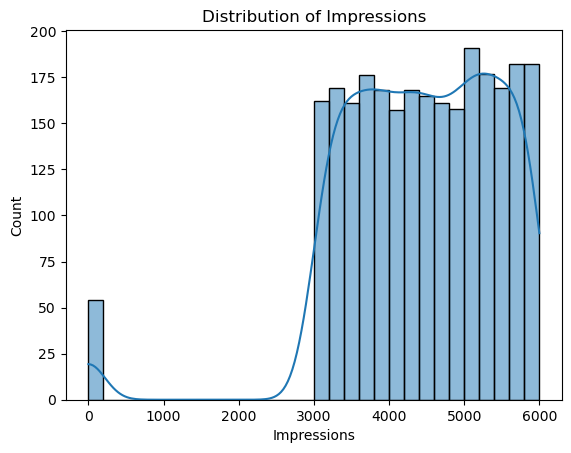

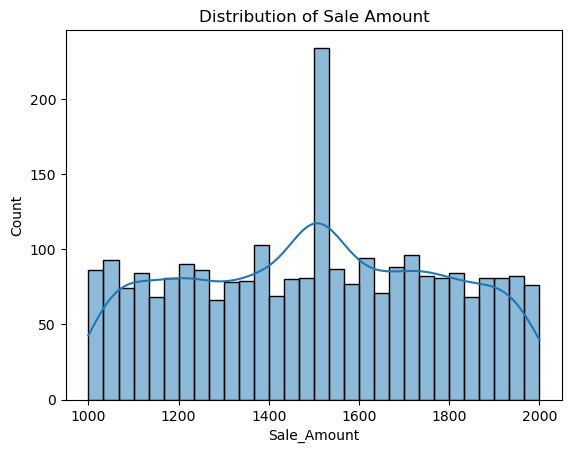

In [44]:
sns.histplot(df['Impressions'], bins=30, kde=True)
plt.title("Distribution of Impressions")
plt.show()

sns.histplot(df['Sale_Amount'], bins=30, kde=True)
plt.title("Distribution of Sale Amount")
plt.show()


## Basic Calculations

CTR (Click‑Through Rate) = Clicks ÷ Impressions → how engaging the ad is.

CPC (Cost Per Click) = Cost ÷ Clicks → how expensive each click is.

ROAS (Return on Ad Spend) = Sale_Amount ÷ Cost → how profitable the ad is.

Conversion Rate = Conversions ÷ Clicks → how effective clicks are at driving sales.

### How engaging is the AD?

In [88]:
df["CTR"] = df["Clicks"]/ df["Impressions"]
df['CTR'].replace([np.inf, -np.inf], np.nan, inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2576\550906857.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CTR'].replace([np.inf, -np.inf], np.nan, inplace=True)


### How expensive each click is?

In [51]:
df["CPC"] = df["Cost"]/ df["Clicks"]

### How profitable is the AD?

In [52]:
df['ROAS'] = df['Sale_Amount'] / df['Cost']

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ad_ID            2600 non-null   string 
 1   Campaign_Name    2600 non-null   string 
 2   Clicks           2600 non-null   int64  
 3   Impressions      2600 non-null   int64  
 4   Cost             2600 non-null   float64
 5   Leads            2600 non-null   int64  
 6   Conversions      2600 non-null   int64  
 7   Conversion Rate  2600 non-null   float64
 8   Sale_Amount      2600 non-null   int64  
 9   Ad_Date          2600 non-null   int64  
 10  Location         2600 non-null   string 
 11  Device           2600 non-null   string 
 12  Keyword          2600 non-null   string 
 13  CTR              2597 non-null   float64
 14  CPC              2600 non-null   float64
 15  ROAS             2600 non-null   float64
dtypes: float64(5), int64(6), string(5)
memory usage: 325.1 KB


## Findings 

### Best Ads

In [83]:
df.groupby('Ad_ID')['ROAS'].mean().sort_values(ascending=False).head(5)

Ad_ID
A2660    11.052632
A2585    10.988278
A3459    10.961485
A1976    10.872432
A3399    10.860421
Name: ROAS, dtype: float64

In [75]:
a=df.groupby('Ad_ID')['ROAS'].mean().sort_values(ascending=False).head(5)
df_a = a.reset_index()
df_a.columns=["Ad_ID", "ROAS"]


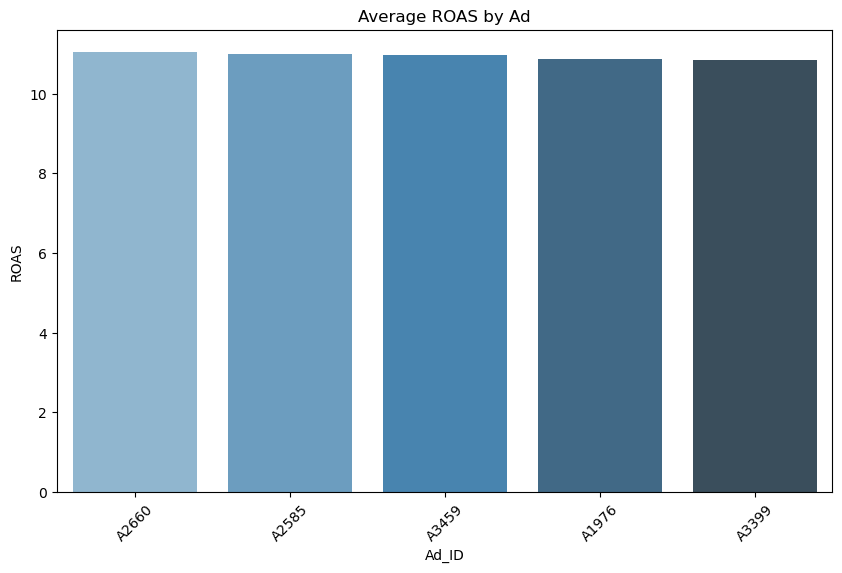

In [86]:
plt.figure(figsize=(10,6))
sns.barplot(x='Ad_ID', y = 'ROAS', data = df_a, palette = "Blues_d", hue = "Ad_ID")
plt.xticks(rotation = 45)
plt.title("Average ROAS by Ad")
plt.show()

### Best Devices

In [89]:
df.groupby('Device')[['CTR','Conversion Rate','ROAS']].mean()


,CTR,Conversion Rate,ROAS
Device,,,
desktop,0.030351,0.048671,7.052607
mobile,0.030893,0.048456,6.980522
tablet,0.030344,0.047622,7.052206


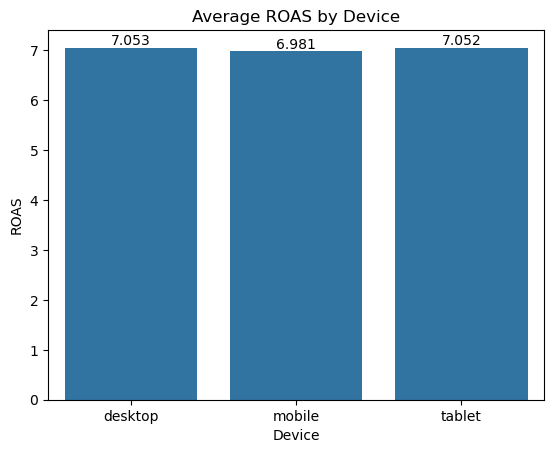

In [95]:
ax = sns.barplot(x='Device', y='ROAS', data=df, estimator='mean', errorbar = None)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom')
plt.title("Average ROAS by Device")
plt.show()



### Best Keywords

In [60]:
df.groupby('Keyword')['Sale_Amount'].sum().sort_values(ascending=False).head(10)


Keyword
learn data analytics       674964
online data analytics      666202
data analytics course      664823
analytics for data         640824
data analytics online      630415
data analytics training    620140
Name: Sale_Amount, dtype: int64

### Inefficient Ads

In [61]:
# Low impressions but conversions > 0
df[(df['Impressions'] < 500) & (df['Conversions'] > 0)]

# High cost but low sales
df[(df['Cost'] > df['Cost'].quantile(0.95)) & (df['Sale_Amount'] < df['Sale_Amount'].median())]


,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword,CTR,CPC,ROAS
100,A1100,data analytics course,179,5162,246.76,16,5,0.050,1052,20241129,hyderabad,desktop,online data analytics,0.034676,1.378547,4.263252
165,A1165,data analytics course,175,5014,247.24,25,7,0.040,1499,15112024,hyderabad,mobile,learn data analytics,0.034902,1.412800,6.062935
200,A1200,data analytics course,199,5067,247.38,24,8,0.059,1365,20241119,hyderabad,mobile,analytics for data,0.039274,1.243116,5.517827
205,A1205,data analytics course,108,4080,247.80,18,4,0.037,1363,20241130,hyderabad,tablet,online data analytics,0.026471,2.294444,5.500404
213,A1213,data analytics course,199,5734,247.99,18,0,0.046,1455,20241111,hyderabad,desktop,data analytics online,0.034705,1.246181,5.867172
218,A1218,data analytics course,0,4883,249.61,10,3,0.046,1464,20241112,hyderabad,tablet,online data analytics,0.000000,inf,5.865150
252,A1252,data analytics course,158,4780,247.20,23,9,0.046,1005,20241124,hyderabad,desktop,learn data analytics,0.033054,1.564557,4.065534
294,A1294,data analytics course,90,0,249.00,21,10,0.046,1245,19112024,hyderabad,mobile,data analytics course,inf,2.766667,5.000000
321,A1321,data analytics course,99,3842,246.30,23,8,0.081,1452,10112024,hyderabad,tablet,online data analytics,0.025768,2.487879,5.895250
419,A1419,data analytics course,165,4613,246.72,19,3,0.018,1055,20241111,hyderabad,tablet,data analytics training,0.035768,1.495273,4.276102


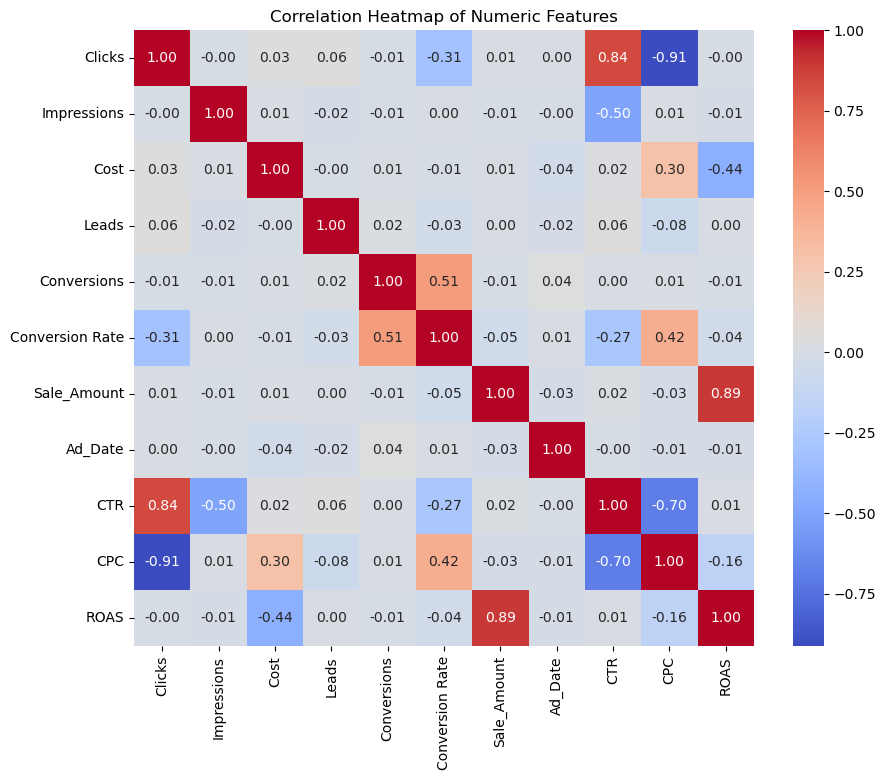

In [96]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()
